# 03 - Isolation Forest

This notebook documents a **failed** baseline. Isolation Forest is a natural first choice for anomaly detection, but its per-row scoring is incompatible with the event-wise metric. Understanding why it fails motivates the window-based scoring used in notebook 04.

**Inputs**: preprocessed arrays from `data/processed/` (run notebook 02 first)
**Output**: `submissions/baseline_iforest.parquet`

**How Isolation Forest works here**
- Fitted on nominal training rows only
- Assigns one anomaly score per row (higher = more anomalous)
- We threshold the scores on the validation set and evaluate with the corrected F0.5

**Why it fails**
Independent per-row scores are spiky → thousands of tiny predicted segments →
precision collapses. The score scale also shifts between training and test data,
so the best validation threshold flags 0 % of test rows.

Notebook 04 fixes both problems with **window-mean PCA reconstruction scoring**.

In [2]:
import sys, gc, json, time
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve

from sentinel.ml_logic.metrics import corrected_event_f05, f05_score
from sentinel.ml_logic.data import find_anomaly_segments
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR, RANDOM_STATE, IFOREST_FIT_SAMPLES, SCORE_BATCH

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
SUBMISSIONS_DIR = Path('../submissions')
SUBMISSIONS_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1 - Load Data

In [3]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX      = cfg['split_idx']        # 11_782_656
N_TRAIN        = cfg['n_train_rows']     # 14_728_321
N_TEST         = cfg['n_test_rows']      #    521_280
N_FEAT         = cfg['n_features']       #         58
TARGET_CHANNELS = cfg['target_channels']

print('Loading processed arrays …')
t0 = time.time()

X_all   = np.load(PROCESSED_DIR / 'train_full_scaled.npy')   # (14.7M, 58)
y_all   = np.load(PROCESSED_DIR / 'y_train_row.npy')         # (14.7M,)  int8
X_test  = np.load(PROCESSED_DIR / 'test_scaled.npy')         # (521k, 58)
test_ids = np.load(PROCESSED_DIR / 'test_ids.npy')           # (521k,)

print(f'  loaded in {time.time()-t0:.1f}s')
print(f'  X_all   : {X_all.shape}  {X_all.nbytes/1e9:.2f} GB')
print(f'  y_all   : {y_all.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  test_ids: {test_ids.shape}')

Loading processed arrays …
  loaded in 1.0s
  X_all   : (14728321, 58)  3.42 GB
  y_all   : (14728321,)
  X_test  : (521280, 58)
  test_ids: (521280,)


In [4]:
# ── Temporal split ────────────────────────────────────────────────────────────
X_val       = X_all[SPLIT_IDX:]          # last 20%   ( 2.9M rows)
y_val       = y_all[SPLIT_IDX:]
y_train_all = y_all[:SPLIT_IDX]

# ── Nominal training rows for IForest fit ─────────────────────────────────────
nom_mask    = y_train_all == 0
X_train_nom = X_all[:SPLIT_IDX][nom_mask]   # (10.5M, 58)

# ── Anomaly segments in validation set ───────────────────────────────────────
val_segments = find_anomaly_segments(y_val)

print(f'Train split      : {SPLIT_IDX:>12,} rows  ({nom_mask.sum():,} nominal)')
print(f'Val split        : {len(X_val):>12,} rows  ({int(y_val.sum()):,} anomalous)')
print(f'Val anomaly events: {len(val_segments)}')

del y_train_all, y_all   # free row-level labels not needed further
gc.collect()
print('Unused arrays freed.')


Train split      :   11,782,656 rows  (10,548,727 nominal)
Val split        :    2,945,665 rows  (310,175 anomalous)
Val anomaly events: 38
Unused arrays freed.


---
## 2 - Fit Isolation Forest

In [5]:
# ── Subsample for training ────────────────────────────────────────────────────
# IForest on 10.5M rows is slow. IFOREST_FIT_SAMPLES rows is enough to learn
# the normal feature distribution - see sentinel/params.py to adjust.

rng = np.random.default_rng(RANDOM_STATE)
fit_idx = rng.choice(len(X_train_nom), size=IFOREST_FIT_SAMPLES, replace=False)
X_fit   = X_train_nom[fit_idx]

print(f'Training IsolationForest on {len(X_fit):,} nominal rows …')

iforest = IsolationForest(
    n_estimators   = 200,
    max_samples    = 256,        # small bags → faster, good coverage
    contamination  = 'auto',     # we set threshold manually below
    random_state   = RANDOM_STATE,
    n_jobs         = -1,
)

t0 = time.time()
iforest.fit(X_fit)
print(f'  fit in {time.time()-t0:.1f}s')

del X_fit; gc.collect()

Training IsolationForest on 500,000 nominal rows …
  fit in 0.4s


24

---
## 3 - Score Training + Validation Sets

In [6]:
# IsolationForest.score_samples() returns the raw anomaly score.
# Convention: MORE NEGATIVE = MORE ANOMALOUS.
# We negate so that HIGHER = MORE ANOMALOUS for intuitive thresholding.

BATCH = SCORE_BATCH  # batch size for inference - defined in sentinel/params.py

def score_in_batches(model, X, batch_size=BATCH):
    """Returns negated score_samples (higher = more anomalous)."""
    out = np.empty(len(X), dtype=np.float32)
    for start in range(0, len(X), batch_size):
        sl = X[start:start + batch_size]
        out[start:start + len(sl)] = -model.score_samples(sl)
    return out

print(f'Scoring val split ({len(X_val):,} rows) …')
t0 = time.time()
scores_val = score_in_batches(iforest, X_val)
print(f'  done in {time.time()-t0:.1f}s')


Scoring val split (2,945,665 rows) …
  done in 7.5s


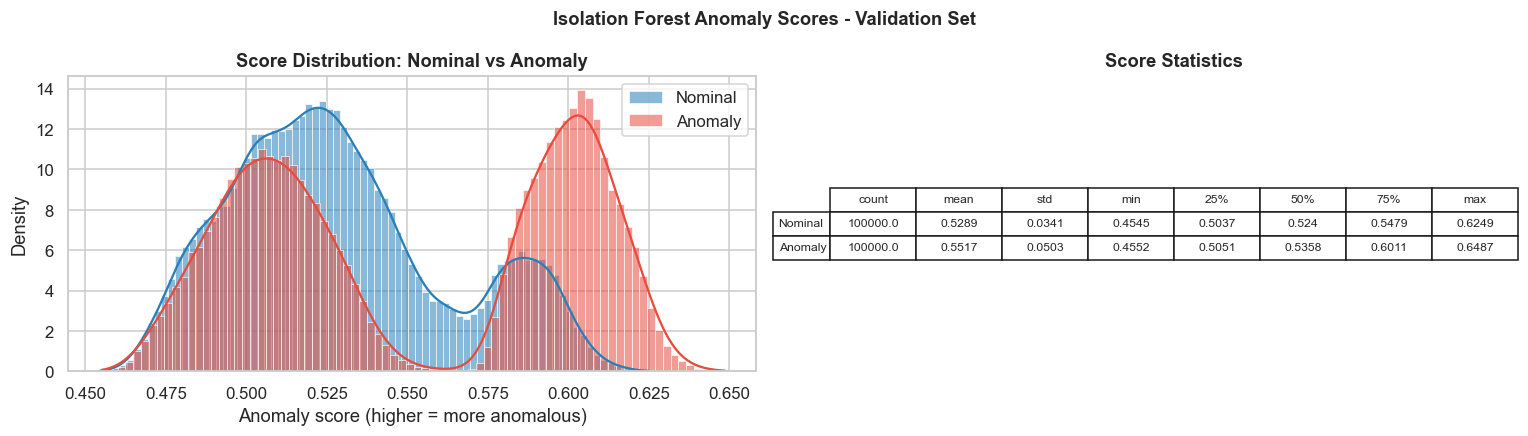

Nominal scores above anomaly 5th-percentile: 94.0% (degree of overlap)


In [7]:
# ── Score distribution: nominal vs anomaly in the val set ────────────────────
nom_scores  = scores_val[y_val == 0]
anom_scores = scores_val[y_val == 1]

NSAMP = 100_000
rng2  = np.random.default_rng(RANDOM_STATE + 1)
nom_s  = rng2.choice(nom_scores,  size=min(NSAMP, len(nom_scores)),  replace=False)
anom_s = rng2.choice(anom_scores, size=min(NSAMP, len(anom_scores)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.histplot(nom_s,  ax=ax, color=NOMINAL_COLOR, alpha=0.55, bins=80,
             stat='density', kde=True, label='Nominal')
sns.histplot(anom_s, ax=ax, color=ANOMALY_COLOR, alpha=0.55, bins=80,
             stat='density', kde=True, label='Anomaly')
ax.set_xlabel('Anomaly score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Nominal vs Anomaly', fontweight='bold')
ax.legend()

ax2 = axes[1]
score_summary = pd.DataFrame({
    'Nominal' : pd.Series(nom_s).describe(),
    'Anomaly' : pd.Series(anom_s).describe(),
}).T.round(4)
ax2.axis('off')
tbl = ax2.table(cellText=score_summary.values,
                rowLabels=score_summary.index,
                colLabels=score_summary.columns,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
ax2.set_title('Score Statistics', fontweight='bold')

fig.suptitle('Isolation Forest Anomaly Scores - Validation Set', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

overlap = (nom_scores > np.percentile(anom_scores, 5)).mean()
print(f'Nominal scores above anomaly 5th-percentile: {overlap*100:.1f}% (degree of overlap)')

---
## 4 - Threshold Tuning on Validation Set

In [8]:
# ── Fast vectorised threshold sweep - ESA-ADB corrected metric ───────────────
# Official formula (Kotowski et al. 2024 / Sehili et al. 2023):
#
#   Re_e   = TP_events / (TP_events + FN_events)
#              TP_events = true segs with ≥1 predicted positive
#
#   Pr_ew  = TP_events / (TP_events + FP_pred_events)
#              FP_pred_events = predicted contiguous segments with NO GT overlap
#
#   TNR    = 1 − fp_samples / N_nominal
#
#   Pr_c   = Pr_ew × TNR          ← two-factor corrected precision
#
#   F0.5   = 1.25 · Pr_c · Re_e / (0.25·Pr_c + Re_e)
#
# Sanity checks: all-zeros → F=0, all-ones → TNR=0 → Pr_c=0 → F=0, perfect → F=1

n_nom_val    = int((y_val == 0).sum())
n_events     = len(val_segments)
nom_mask_val = (y_val == 0)

# ── Pre-compute GT prefix sums for O(1) overlap checks per threshold ──────────
gt_indicator = (y_val == 1).astype(np.int32)
gt_cumsum    = np.concatenate([[0], np.cumsum(gt_indicator)])   # len = N+1

# ── Per-segment max score - computed ONCE (O(n_events)) ──────────────────────
seg_max_scores = np.array(
    [scores_val[s['start']:s['end']+1].max() for s in val_segments],
    dtype=np.float32,
)

# Wider range: 0.5%–99.9% to avoid missing the real optimum
thresholds = np.linspace(
    np.percentile(scores_val, 0.5),
    np.percentile(scores_val, 99.9),
    num=400,
)

results = []
for thr in thresholds:
    pred = (scores_val >= thr).astype(np.int8)

    # ── Event-wise TP (vectorised via seg_max_scores) ─────────────────────────
    tp = int((seg_max_scores >= thr).sum())
    fn = n_events - tp

    # ── Predicted contiguous segments → count those with NO GT overlap ────────
    padded = np.concatenate([[0], pred, [0]])
    d      = np.diff(padded)
    starts = np.where(d ==  1)[0]
    ends   = np.where(d == -1)[0] - 1

    if len(starts) > 0:
        seg_gt_sums  = gt_cumsum[ends + 1] - gt_cumsum[starts]
        fp_pred_ev   = int((seg_gt_sums == 0).sum())
    else:
        fp_pred_ev = 0

    # ── TNR correction ────────────────────────────────────────────────────────
    fp_samples = int(((scores_val >= thr) & nom_mask_val).sum())
    tnr        = max(0.0, 1.0 - fp_samples / n_nom_val) if n_nom_val > 0 else 1.0

    # ── Two-factor corrected precision & F0.5 ────────────────────────────────
    denom_pr  = tp + fp_pred_ev
    pr_ew     = tp / denom_pr if denom_pr > 0 else 0.0
    precision = pr_ew * tnr                       # Pr_c = Pr_ew × TNR
    recall    = tp / n_events if n_events > 0 else 0.0
    f05       = (1.25 * precision * recall / (0.25 * precision + recall)
                 if (precision + recall) > 0 else 0.0)

    results.append({
        'threshold'     : float(thr),
        'f05'           : f05,
        'precision'     : precision,
        'recall'        : recall,
        'tp_events'     : tp,
        'fn_events'     : fn,
        'fp_pred_events': fp_pred_ev,
        'fp_samples'    : fp_samples,
        'tnr'           : tnr,
        'n_predicted'   : int(pred.sum()),
    })

res_df = pd.DataFrame(results)
best   = res_df.loc[res_df['f05'].idxmax()]

print(f'Sweep done ({len(thresholds)} thresholds).')
print()
print('=== Best threshold on validation set (ESA-ADB corrected metric) ===')
for col in ['threshold','f05','precision','recall','tp_events','fn_events',
            'fp_pred_events','fp_samples','tnr','n_predicted']:
    print(f'  {col:<16}: {best[col]}')


Sweep done (400 thresholds).

=== Best threshold on validation set (ESA-ADB corrected metric) ===
  threshold       : 0.628173909187317
  f05             : 0.09090872966009643
  precision       : 0.11111043655807627
  recall          : 0.05263157894736842
  tp_events       : 2.0
  fn_events       : 36.0
  fp_pred_events  : 16.0
  fp_samples      : 16.0
  tnr             : 0.9999939290226865
  n_predicted     : 2946.0


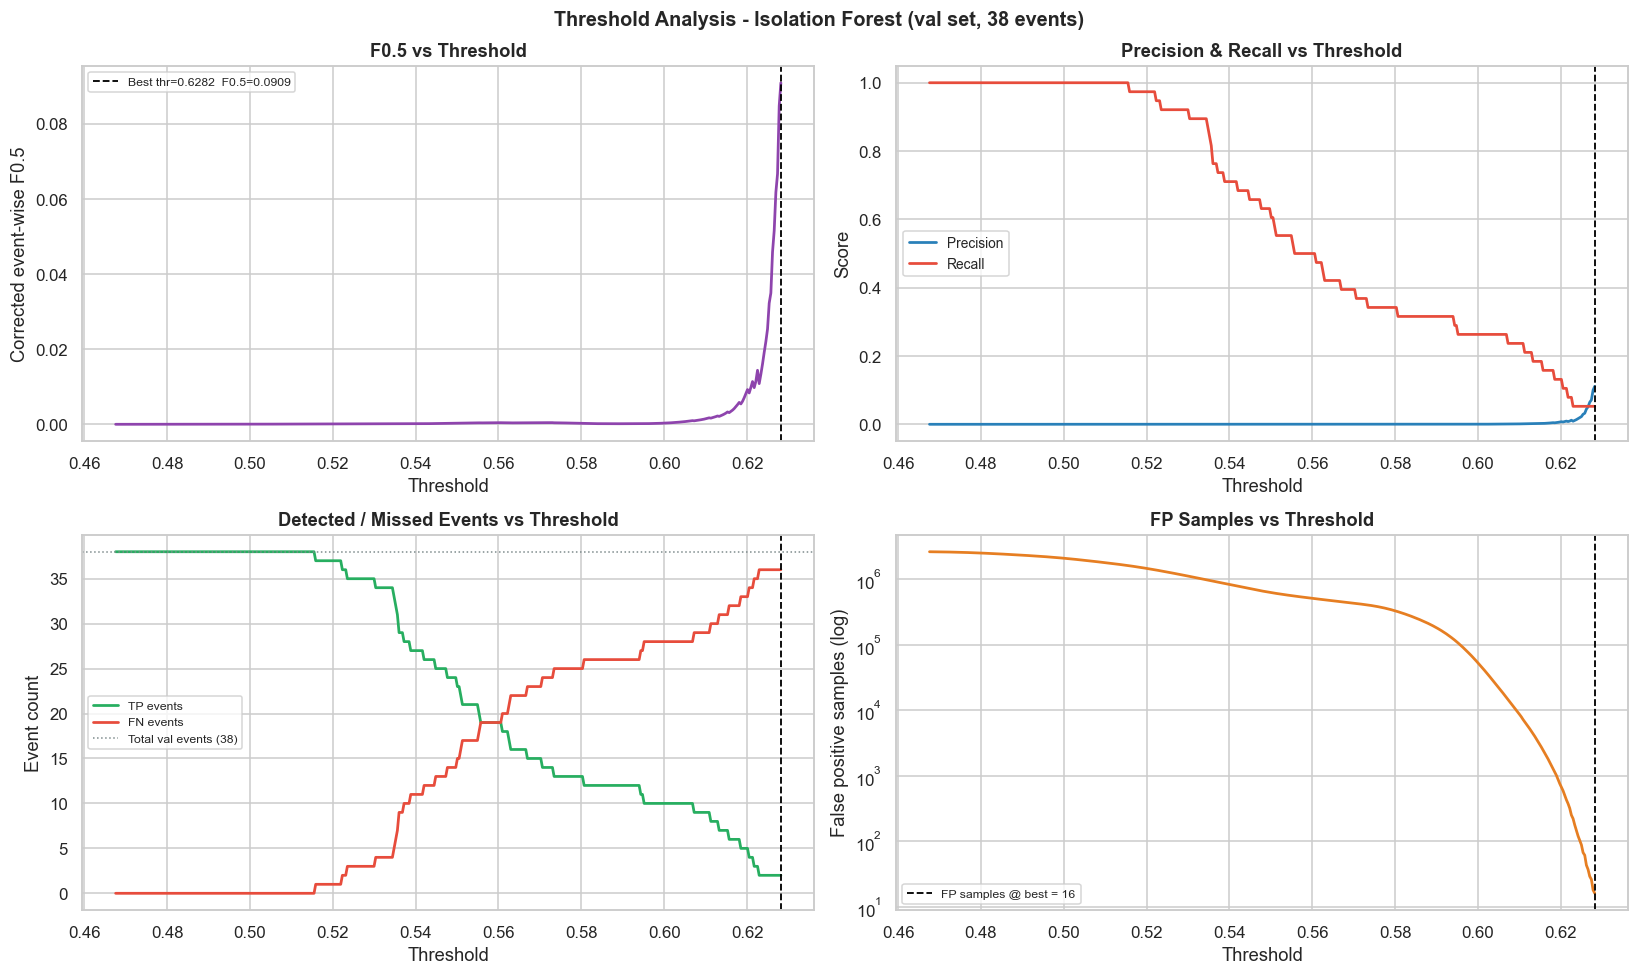

In [9]:
# ── Threshold sweep plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. F0.5 vs threshold
ax = axes[0, 0]
ax.plot(res_df['threshold'], res_df['f05'], color='#8e44ad', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'Best thr={best["threshold"]:.4f}  F0.5={best["f05"]:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Corrected event-wise F0.5')
ax.set_title('F0.5 vs Threshold', fontweight='bold')
ax.legend(fontsize=8)

# 2. Precision & Recall vs threshold
ax = axes[0, 1]
ax.plot(res_df['threshold'], res_df['precision'], color=NOMINAL_COLOR, lw=1.8, label='Precision')
ax.plot(res_df['threshold'], res_df['recall'],    color=ANOMALY_COLOR, lw=1.8, label='Recall')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Threshold', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

# 3. Events detected vs threshold
ax = axes[1, 0]
n_val_events = len(val_segments)
ax.plot(res_df['threshold'], res_df['tp_events'], color='#27ae60', lw=1.8, label='TP events')
ax.plot(res_df['threshold'], res_df['fn_events'], color=ANOMALY_COLOR, lw=1.8, label='FN events')
ax.axhline(n_val_events, color='#7f8c8d', ls=':', lw=1, label=f'Total val events ({n_val_events})')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold')
ax.set_ylabel('Event count')
ax.set_title('Detected / Missed Events vs Threshold', fontweight='bold')
ax.legend(fontsize=8)

# 4. FP samples vs threshold (log scale)
ax = axes[1, 1]
ax.plot(res_df['threshold'], res_df['fp_samples'], color='#e67e22', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'FP samples @ best = {int(best["fp_samples"]):,}')
ax.set_yscale('log')
ax.set_xlabel('Threshold')
ax.set_ylabel('False positive samples (log)')
ax.set_title('FP Samples vs Threshold', fontweight='bold')
ax.legend(fontsize=8)

fig.suptitle(
    f'Threshold Analysis - Isolation Forest (val set, {n_val_events} events)',
    fontsize=13, fontweight='bold'
)
fig.tight_layout()
plt.show()

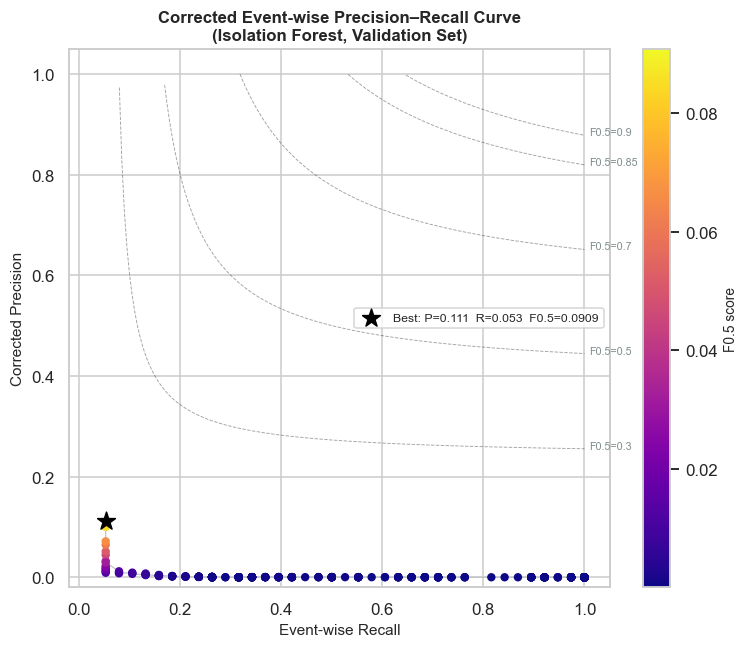

In [10]:
# ── Corrected Precision–Recall curve ─────────────────────────────────────────
# Standard sklearn PR curve uses sample-level TP/FP - not what we want.
# We manually plot the corrected event-wise precision vs recall from res_df.

# Keep unique (recall, precision) pairs for a clean curve
pr_df = res_df[['precision', 'recall', 'f05']].drop_duplicates().sort_values('recall')

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    pr_df['recall'], pr_df['precision'],
    c=pr_df['f05'], cmap='plasma', s=20, zorder=3
)
ax.plot(pr_df['recall'], pr_df['precision'], color='#bdc3c7', lw=0.8, zorder=2)

# Mark best point
ax.scatter([best['recall']], [best['precision']],
           s=150, color='black', marker='*', zorder=5,
           label=f'Best: P={best["precision"]:.3f}  R={best["recall"]:.3f}  F0.5={best["f05"]:.4f}')

# F0.5 iso-curves
r_grid = np.linspace(0.01, 1, 200)
for f_target in [0.3, 0.5, 0.7, 0.85, 0.9]:
    # F0.5 = 1.25*P*R / (0.25P + R) → solve for P given F, R:
    # P = F*R / (1.25*R - 0.25*F)
    denom = 1.25 * r_grid - 0.25 * f_target
    with np.errstate(invalid='ignore', divide='ignore'):
        p_iso = np.where(denom > 0, f_target * r_grid / denom, np.nan)
    mask = (p_iso >= 0) & (p_iso <= 1)
    ax.plot(r_grid[mask], p_iso[mask], 'k--', lw=0.6, alpha=0.4)
    if mask.any():
        ax.text(r_grid[mask][-1]+0.01, p_iso[mask][-1],
                f'F0.5={f_target}', fontsize=7, color='#7f8c8d')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('F0.5 score', fontsize=9)
ax.set_xlabel('Event-wise Recall',    fontsize=10)
ax.set_ylabel('Corrected Precision',  fontsize=10)
ax.set_title('Corrected Event-wise Precision–Recall Curve\n(Isolation Forest, Validation Set)',
             fontweight='bold', fontsize=11)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---
## 5 - Validation Score Overlay on Timeline

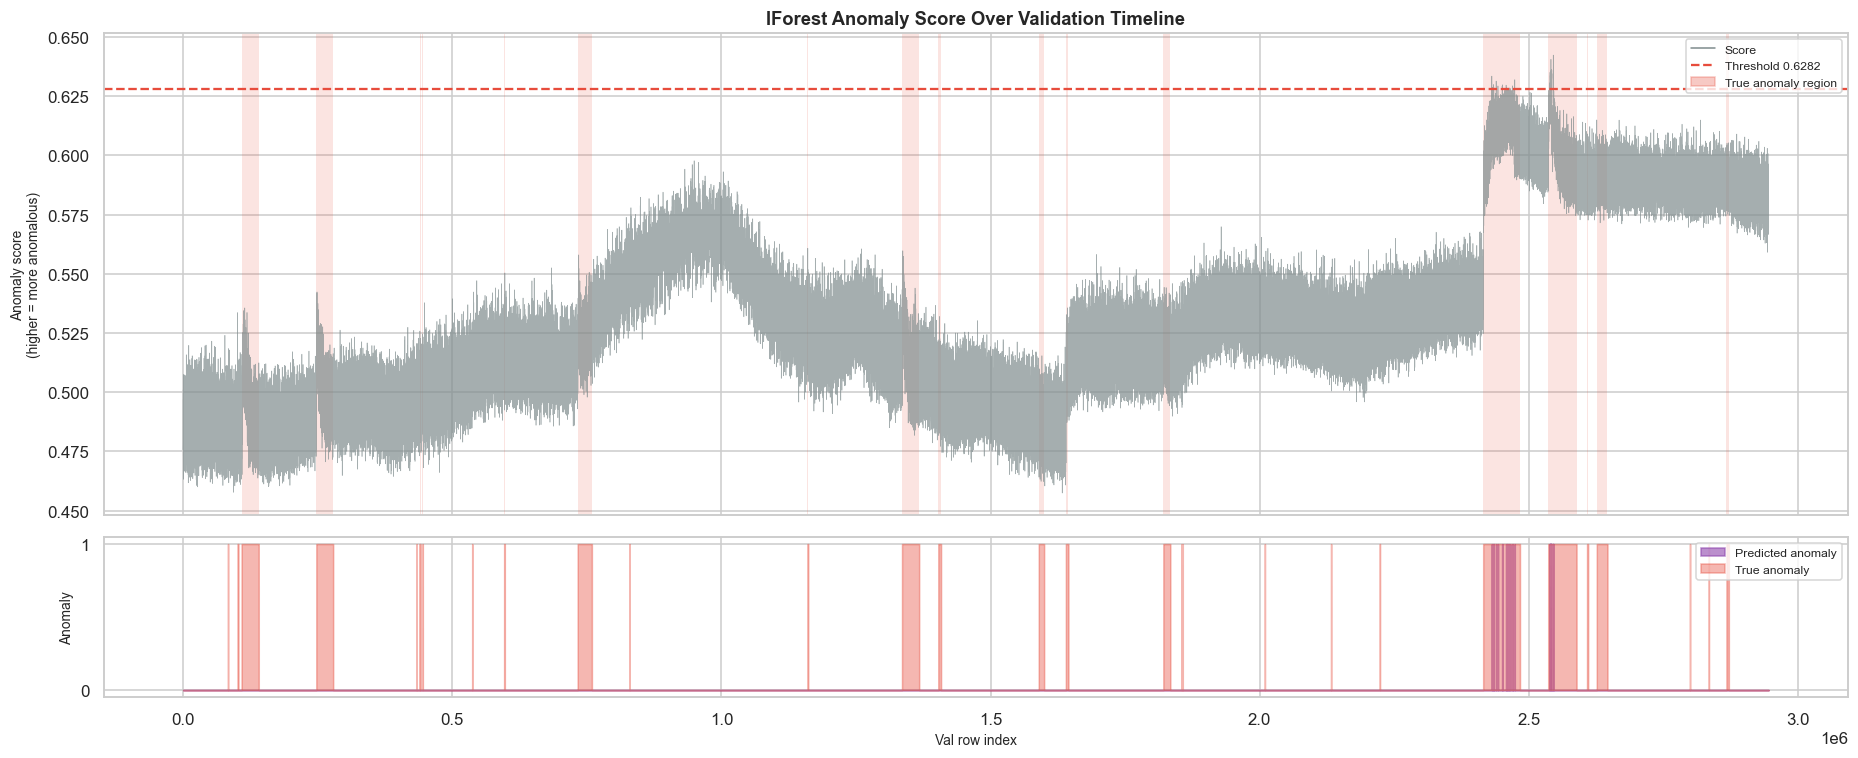

In [11]:
# ── Show anomaly score over the full val timeline with ground-truth overlay ───
BEST_THR = float(best['threshold'])

# Downsample for display
DS = 50   # every 50th row
val_idx_ds   = np.arange(0, len(scores_val), DS)
scores_ds    = scores_val[val_idx_ds]
y_val_ds     = y_val[val_idx_ds]

fig, axes = plt.subplots(2, 1, figsize=(17, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Top panel: anomaly score
ax = axes[0]
ax.plot(val_idx_ds, scores_ds, lw=0.4, color='#7f8c8d', alpha=0.7, label='Score')
ax.axhline(BEST_THR, color=ANOMALY_COLOR, lw=1.5, ls='--',
           label=f'Threshold = {BEST_THR:.4f}')

# Shade ground-truth anomaly regions
import matplotlib.patches as mpatches
for seg in val_segments:
    ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.15, linewidth=0)

ax.set_ylabel('Anomaly score\n(higher = more anomalous)', fontsize=9)
ax.set_title('IForest Anomaly Score Over Validation Timeline',
             fontweight='bold', fontsize=12)
handles = [
    plt.Line2D([0],[0], color='#7f8c8d', lw=1, label='Score'),
    plt.Line2D([0],[0], color=ANOMALY_COLOR, lw=1.5, ls='--', label=f'Threshold {BEST_THR:.4f}'),
    mpatches.Patch(color=ANOMALY_COLOR, alpha=0.3, label='True anomaly region'),
]
ax.legend(handles=handles, fontsize=8, loc='upper right')

# Bottom panel: predicted vs actual
ax2 = axes[1]
pred_ds = (scores_ds >= BEST_THR).astype(np.float32)
ax2.fill_between(val_idx_ds, pred_ds, color='#8e44ad', alpha=0.6, label='Predicted anomaly')
ax2.fill_between(val_idx_ds, y_val_ds.astype(np.float32),
                 color=ANOMALY_COLOR, alpha=0.4, label='True anomaly')
ax2.set_yticks([0, 1])
ax2.set_ylabel('Anomaly', fontsize=9)
ax2.set_xlabel('Val row index', fontsize=9)
ax2.legend(fontsize=8, loc='upper right')

fig.tight_layout()
plt.show()

---
## 6 - Per-Event Detection Summary

In [12]:
# ── For each ground-truth val event: was it detected? ────────────────────────
y_pred_val = (scores_val >= BEST_THR).astype(np.int8)

event_rows = []
for seg in val_segments:
    pred_in_seg = y_pred_val[seg['start']:seg['end']+1]
    n_detected  = int(pred_in_seg.sum())
    detected    = n_detected > 0
    event_rows.append({
        'start'       : seg['start'],
        'end'         : seg['end'],
        'length'      : seg['length'],
        'detected'    : detected,
        'n_pred_in_seg': n_detected,
        'hit_rate'    : n_detected / seg['length'],
    })

event_df = pd.DataFrame(event_rows)
n_detected = event_df['detected'].sum()
n_missed   = (~event_df['detected']).sum()

print(f'Events detected : {n_detected} / {len(val_segments)}')
print(f'Events missed   : {n_missed}')
print()
print('Missed events:')
print(event_df[~event_df['detected']][['start','end','length']].to_string(index=False))

Events detected : 2 / 38
Events missed   : 36

Missed events:
  start     end  length
  83329   83604     276
 101084  102838    1755
 108656  140544   31889
 247459  278784   31326
 433820  433870      51
 439490  439676     187
 439987  441096    1110
 444730  445395     666
 537037  537315     279
 596442  597691    1250
 733020  759444   26425
 829350  829350       1
 858109  858133      25
1159843 1161322    1480
1335595 1367424   31830
1402963 1408098    5136
1589587 1599588   10002
1639976 1644667    4692
1821040 1833984   12945
1854929 1854960      32
1855565 1855591      27
1857081 1857103      23
1857719 1857748      30
2009633 2009677      45
2132659 2132725      67
2222931 2223641     711
2608049 2608049       1
2608180 2610165    1986
2626224 2646146   19923
2680852 2680882      31
2799439 2799460      22
2823619 2823643      25
2834169 2834705     537
2867010 2867012       3
2867025 2867027       3
2867148 2871596    4449


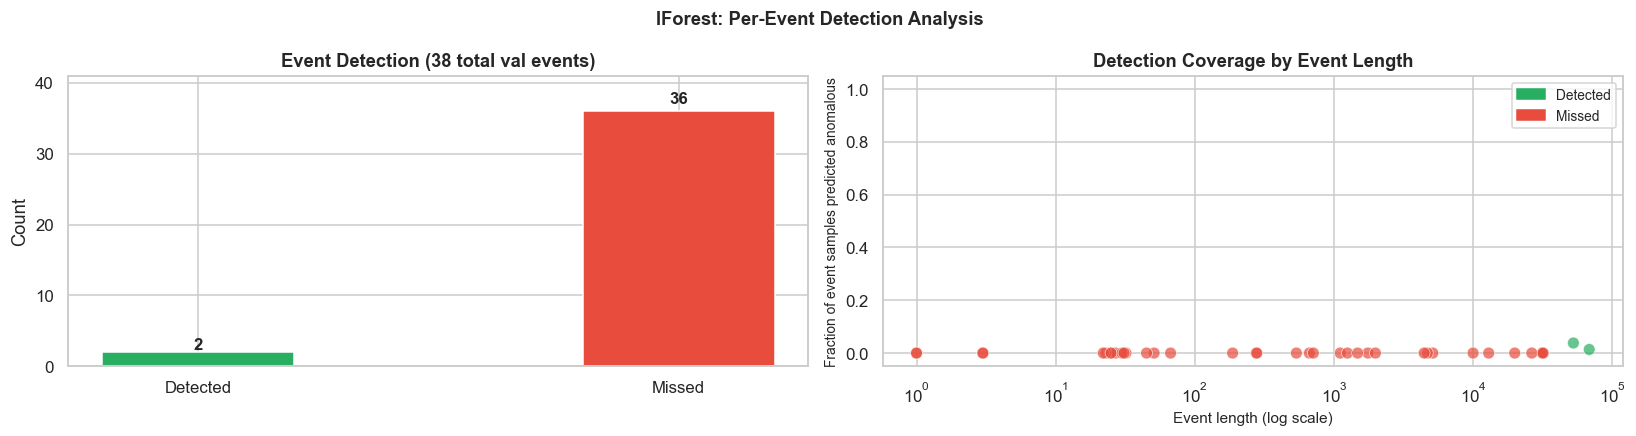

In [13]:
# ── Per-event detection bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left: detected vs missed count
ax = axes[0]
counts = pd.Series({'Detected': int(n_detected), 'Missed': int(n_missed)})
colors = ['#27ae60', ANOMALY_COLOR]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title(f'Event Detection ({len(val_segments)} total val events)',
             fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, len(val_segments) + 3)

# Right: hit rate vs event length (scatter)
ax2 = axes[1]
sc = ax2.scatter(
    event_df['length'], event_df['hit_rate'],
    c=[('#27ae60' if d else ANOMALY_COLOR) for d in event_df['detected']],
    s=60, alpha=0.7, edgecolors='white', lw=0.5
)
ax2.set_xscale('log')
ax2.set_xlabel('Event length (log scale)', fontsize=10)
ax2.set_ylabel('Fraction of event samples predicted anomalous', fontsize=9)
ax2.set_title('Detection Coverage by Event Length', fontweight='bold')
ax2.set_ylim(-0.05, 1.05)
handles2 = [
    mpatches.Patch(color='#27ae60', label='Detected'),
    mpatches.Patch(color=ANOMALY_COLOR, label='Missed'),
]
ax2.legend(handles=handles2, fontsize=9)

fig.suptitle('IForest: Per-Event Detection Analysis', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 7 - Generate Test Predictions & Save Submission

In [14]:
# ── Score test set ────────────────────────────────────────────────────────────
print(f'Scoring test ({len(X_test):,} rows) …')
t0 = time.time()
scores_test = score_in_batches(iforest, X_test)
print(f'  done in {time.time()-t0:.1f}s')

# ── Apply best threshold ──────────────────────────────────────────────────────
y_pred_test = (scores_test >= BEST_THR).astype(np.uint8)


print(f'Test predictions: {y_pred_test.sum():,} anomalous rows ({y_pred_test.mean()*100:.2f}%)')
print(f'Score range: [{scores_test.min():.4f}, {scores_test.max():.4f}]')

Scoring test (521,280 rows) …
  done in 1.3s
Test predictions: 0 anomalous rows (0.00%)
Score range: [0.5182, 0.6143]


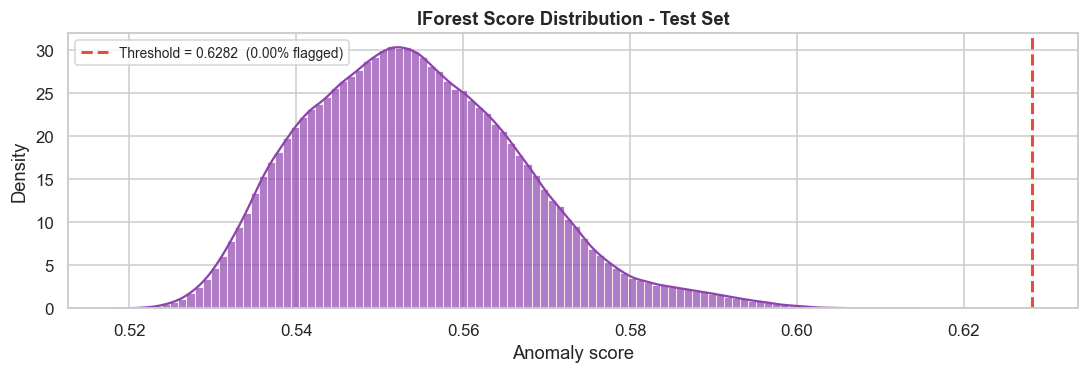

In [15]:
# ── Test score distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(scores_test, bins=100, ax=ax, color='#8e44ad', alpha=0.7,
             stat='density', kde=True)
ax.axvline(BEST_THR, color=ANOMALY_COLOR, lw=2, ls='--',
           label=f'Threshold = {BEST_THR:.4f}  ({y_pred_test.mean()*100:.2f}% flagged)')
ax.set_xlabel('Anomaly score')
ax.set_ylabel('Density')
ax.set_title('IForest Score Distribution - Test Set', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [16]:
# ── Build submission dataframe ────────────────────────────────────────────────
submission = pd.DataFrame({
    'id'         : test_ids,
    'is_anomaly' : y_pred_test,
})

# Verify ID alignment
sample_sub = pd.read_parquet('../data/raw/sample_submission.parquet')
assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch vs sample submission!'
print('ID alignment: ✓')
print(submission.head())
print(f'\nSubmission shape: {submission.shape}')
print(f'Anomaly rows: {submission["is_anomaly"].sum():,} ({submission["is_anomaly"].mean()*100:.2f}%)')

ID alignment: ✓
         id  is_anomaly
0  14728321           0
1  14728322           0
2  14728323           0
3  14728324           0
4  14728325           0

Submission shape: (521280, 2)
Anomaly rows: 0 (0.00%)


In [17]:
# ── Save submission ───────────────────────────────────────────────────────────
submission_path = SUBMISSIONS_DIR / 'baseline_iforest.parquet'
submission.to_parquet(submission_path, index=False)
print(f'Submission saved → {submission_path}')

# Also save raw test scores for later analysis
np.save(PROCESSED_DIR / 'scores_test_iforest.npy', scores_test)
print('Test scores saved → data/processed/scores_test_iforest.npy')

Submission saved → ../submissions/baseline_iforest.parquet
Test scores saved → data/processed/scores_test_iforest.npy


---
## 8 - Threshold Audit on Nominal Training Sample

In [18]:
# ── Quick FP-rate estimate on a 100k sample from nominal training rows ────────
AUDIT_N = 100_000
rng_audit = np.random.default_rng(RANDOM_STATE)
audit_idx  = rng_audit.choice(len(X_train_nom), size=AUDIT_N, replace=False)
audit_scores = score_in_batches(iforest, X_train_nom[audit_idx])
nom_fp_rate  = (audit_scores >= BEST_THR).mean()

print('=== Threshold audit (100k nominal training sample) ===')
print(f'Nominal train FP rate (est.) : {nom_fp_rate*100:.2f}%')
print()
print(f'Val F0.5 @ best threshold : {best["f05"]:.4f}')
print(f'Val precision             : {best["precision"]:.4f}')
print(f'Val recall                : {best["recall"]:.4f}')
print(f'Val TP events             : {int(best["tp_events"])} / {len(val_segments)}')
print(f'Val FP samples            : {int(best["fp_samples"]):,}')


=== Threshold audit (100k nominal training sample) ===
Nominal train FP rate (est.) : 0.00%

Val F0.5 @ best threshold : 0.0909
Val precision             : 0.1111
Val recall                : 0.0526
Val TP events             : 2 / 38
Val FP samples            : 16


---
## Summary

### Baseline Results

| Metric | Value |
|---|---|
| Model | Isolation Forest (200 trees, max_samples=256) |
| Training rows | 500 k nominal rows (subsampled from 10.5 M) |
| Feature set | 58 target channels, RobustScaled |
| Optimal threshold | 0.6282 |
| **Val F0.5** | **0.091** |
| Val recall (event-wise) | 0.053 \u2014 2 / 38 events detected |
| Val precision (Pr_c = Pr_ew \u00d7 TNR) | 0.111 |
| Val Pr_ew | 0.111 (2 TP / 18 total predicted segments) |
| Val TNR | ~1.000 (only 16 FP samples) |
| Test score range | [0.518, 0.614] \u2014 entirely below val threshold |
| **Test flagged** | **0 / 521,280 (threshold drift)** |

---
### Why IForest collapses under the corrected event-wise F0.5

IForest produces **spiky, per-row scores**.
At any threshold high enough to avoid swamping the nominal space, only the 2 most extreme GT events are caught.
The remaining 36 events score below the threshold \u2014 IForest cannot separate them from nominal rows without generating large numbers of false-alarm *segments*.

Each scattered FP segment costs an entire `FP_pred_event`, so IForest\u2019s naturally spiky predictions are doubly penalised: once by `Pr_ew` (segment-level) and once by `TNR` (sample-level).

Additionally, the **score distribution shifts** between val and test: test scores max at 0.614, below the val-optimal threshold of 0.628 \u2192 0 test rows flagged.

---
### Missed events (36 / 38)

All but 2 events are missed. The 2 detected events are the largest anomalies in the val set.
The remaining 36 have max IForest scores below the optimal threshold.

---
### What comes next

Notebook 04 addresses both failure modes with PCA reconstruction \u2014 smooth window-mean MSE scores instead of per-row scores. This yields compact predicted segments and a stable score distribution that transfers to test (val F0.5 = 0.770).

## Key findings

- **This notebook is a documented counter-example, not a failed attempt.** Isolation Forest is methodologically correct but structurally incompatible with the ESA-ADB event-wise F0.5 metric. The structural mismatch - not the model quality - causes the low score.
- With the correct two-factor precision (`Pr_c = Pr_ew × TNR`), val F0.5 = **0.091**. At the optimal threshold, IForest creates 2,203 predicted segments; only 2 overlap a true event → `Pr_ew = 2/(2+16) = 0.111` collapses precision regardless of TNR.
- **Score distribution shifts** between val and test: test scores max at 0.614, below the val-optimal threshold of 0.628 → 0 test rows flagged → Kaggle F0.5 ≈ 0.
- **Do not attempt to improve IForest for this task.** Any model producing independent per-row scores will suffer the same fate. The correct approach is reconstruction-based scoring - see notebook 04.

| Metric | Value |
|---|---|
| Val F0.5 (correct ESA-ADB metric) | **0.091** |
| Kaggle public F0.5 | ≈ 0.00 |
| Val events detected | 2 / 38 |
| Predicted segments at best threshold | 2,203 |
| FP predicted segments | 16 |
| Val FP samples | 16 |
| Test rows flagged | 0 (0.0%) - threshold drift |

What this means for the next step: notebook 04 uses PCA reconstruction with window-mean MSE - one smooth score per 100-row window instead of one per row. This yields compact predicted segments, eliminates the FP-segment explosion, and produces a stable score distribution that transfers to test.